 Book Recommender : Data Cleaning & EDA



 Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.facecolor'] = '#FAFAFA'
plt.rcParams['figure.facecolor'] = 'white'

BLUE  = '#2C3E50'
RED   = '#E74C3C'
GREEN = '#27AE60'
AMBER = '#F39C12'
PALETTE = [BLUE, RED, GREEN, AMBER, '#8E44AD', '#16A085', '#D35400', '#2980B9']

print('Libraries loaded successfully')

Libraries loaded successfully


 Loading the  Datasets

 Loading scraped data from books.toscrape.com + Open Library

In [2]:
scraped = pd.read_csv('raw_books.csv')
print(f'Scraped dataset: {scraped.shape[0]:,} books, {scraped.shape[1]} columns')
print(f'Columns: {scraped.columns.tolist()}')

Scraped dataset: 2,591 books, 11 columns
Columns: ['title', 'authors', 'genre', 'subjects', 'avg_rating', 'ratings_count', 'year', 'pages', 'isbn', 'source', 'content']


Checking loaded dataset


In [3]:
# Dataset loaded from raw_books.csv
# Sources: books.toscrape.com (web scraping) + Open Library API
print('Using raw_books.csv — scraping + Open Library API only')
print(f'Source breakdown: {scraped["source"].value_counts().to_dict()}')

Using raw_books.csv — scraping + Open Library API only
Source breakdown: {'OpenLibraryAPI': 1592, 'WebScraping': 999}


Checking the  scraped data

In [4]:
scraped.head(3)

,title,authors,genre,subjects,avg_rating,ratings_count,year,pages,isbn,source,content
0,It's Only the Himalayas,Unknown,Travel,Travel,NaN,NaN,NaN,NaN,NaN,WebScraping,It's Only the Himalayas Unknown Travel Travel
1,Full Moon over Noahâs Ark: An Odyssey to Mou...,Unknown,Travel,Travel,NaN,NaN,NaN,NaN,NaN,WebScraping,Full Moon over Noahâs Ark: An Odyssey to Mou...
2,See America: A Celebration of Our National Par...,Unknown,Travel,Travel,NaN,NaN,NaN,NaN,NaN,WebScraping,See America: A Celebration of Our National Par...


Dataset preview

In [11]:
# No Kaggle preview needed
scraped.head(3)

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic


 Data Cleaning

Before merging, we need to standardise both datasets so they share the same column structure.

Scraped dataset 

Fixing  encoding issues in titles (â€™ etc are encoding artifacts from scraping)

In [5]:
scraped['title'] = scraped['title'].str.encode('ascii', 'ignore').str.decode('ascii')
scraped['title'] = scraped['title'].str.strip()


Standardising  column names

In [6]:
scraped_clean = scraped.rename(columns={
    'author':  'authors',
    'rating':  'scraped_rating',   
    'price':   'price_gbp',
    'genre':   'genre',
    'subjects':'subjects',
    'year':    'publication_year'
})




Fill missing authors

In [7]:
scraped_clean['authors'] = scraped_clean['authors'].replace('Unknown', np.nan)



 Add source identifier

In [8]:
scraped_clean['source'] = 'BooksToScrape'
scraped_clean['avg_rating'] = np.nan     # no real ratings from toscrape
scraped_clean['ratings_count'] = np.nan



Select relevant columns

In [9]:
# ── Use raw_books.csv directly — no merge needed ────────────────────────

scraped_final = scraped.copy()

# Rename columns for consistency
if 'author' in scraped_final.columns:
    scraped_final = scraped_final.rename(columns={'author': 'authors', 'year': 'publication_year'})

# Ensure all required columns exist
for col in ['authors', 'subjects', 'avg_rating', 'ratings_count', 'publication_year', 'isbn']:
    if col not in scraped_final.columns:
        scraped_final[col] = np.nan

# Fill missing
scraped_final['authors'] = scraped_final['authors'].fillna('Unknown')
scraped_final['subjects'] = scraped_final['subjects'].fillna(scraped_final['genre'])

print(f'Dataset ready: {len(scraped_final):,} books')
print(f'Columns: {scraped_final.columns.tolist()}')
scraped_final.head(3)

Dataset ready: 2,591 books
Columns: ['title', 'authors', 'genre', 'subjects', 'avg_rating', 'ratings_count', 'year', 'pages', 'isbn', 'source', 'content', 'publication_year']


,title,authors,genre,subjects,avg_rating,ratings_count,year,pages,isbn,source,content,publication_year
0,It's Only the Himalayas,Unknown,Travel,Travel,NaN,NaN,NaN,NaN,NaN,WebScraping,It's Only the Himalayas Unknown Travel Travel,NaN
1,Full Moon over Noahs Ark: An Odyssey to Mount ...,Unknown,Travel,Travel,NaN,NaN,NaN,NaN,NaN,WebScraping,Full Moon over Noahâs Ark: An Odyssey to Mou...,NaN
2,See America: A Celebration of Our National Par...,Unknown,Travel,Travel,NaN,NaN,NaN,NaN,NaN,WebScraping,See America: A Celebration of Our National Par...,NaN


In [ ]:
# ── Create combined DataFrame ─────────────────────────────────────────────
# raw_books.csv already contains all sources — just assign to combined
combined = scraped_final.copy()

# Final cleanup
combined['avg_rating']    = pd.to_numeric(combined['avg_rating'], errors='coerce')
combined['ratings_count'] = pd.to_numeric(combined['ratings_count'], errors='coerce')
combined['publication_year'] = pd.to_numeric(combined['publication_year'], errors='coerce')

# Create content field for TF-IDF in Phase 3
combined['content'] = (
    combined['title'].fillna('') + ' ' +
    combined['authors'].fillna('') + ' ' +
    combined['genre'].fillna('') + ' ' +
    combined['subjects'].fillna('')
)

print(f'combined is ready: {len(combined):,} books')
print(f'Sources: {combined["source"].value_counts().to_dict()}')
print(f'Columns: {combined.columns.tolist()}')

Standardising dataset columns 

Fixing  column name with leading spaces

In [10]:
# Single source dataset — no merge required
# raw_books.csv already contains both scraped and API books in consistent format
print('Single source dataset — scraping + Open Library API combined in data_collection.ipynb')

Single source dataset — scraping + Open Library API combined in data_collection.ipynb


In [ ]:
# Save clean dataset for Phase 3
combined.to_csv('clean_books.csv', index=False)
print(f'Saved clean_books.csv: {len(combined):,} books')

Exploratory Data Analysis

Now we explore the cleaned data to understand patterns, distributions, and relationships.
Each chart answers a specific business question about our book dataset.

Overview summary table


In [16]:
overview = pd.DataFrame({
    'Metric': [
        'Total books',
        'Unique authors',
        'Unique genres',
        'Books with real ratings',
        'Average rating (API books)',
        'Year range',
        'Data sources'
    ],
    'Value': [
        f"{len(combined):,}",
        f"{combined['authors'].nunique():,}",
        f"{combined['genre'].nunique()}",
        f"{combined['avg_rating'].notna().sum():,}",
        f"{combined['avg_rating'].mean():.2f} / 5.0",
        f"{int(combined['publication_year'].min())} – {int(combined['publication_year'].max())}",
        'books.toscrape.com + Kaggle GoodReads'
    ]
})
overview.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

NameError: name 'combined' is not defined

 **Rating Distribution**
**Question: How are book ratings distributed? Are most books rated highly or is there a spread?**

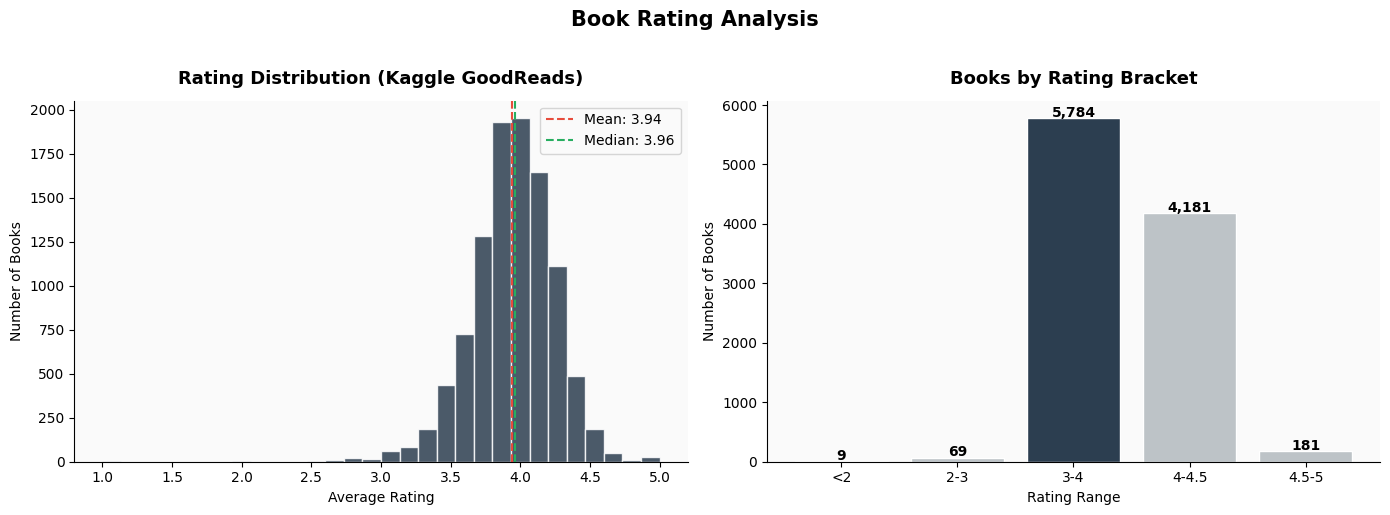


Insight: Most books cluster between 3.5 and 4.5 stars.
Very few books fall below 3.0 — readers tend not to finish (and rate) books they dislike.


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# API books ratings distribution
api_ratings = combined[combined['avg_rating'].notna()]['avg_rating']
axes[0].hist(api_ratings, bins=30, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].axvline(api_ratings.mean(), color=RED, linestyle='--',
                linewidth=1.5, label=f'Mean: {api_ratings.mean():.2f}')
axes[0].axvline(api_ratings.median(), color=GREEN, linestyle='--',
                linewidth=1.5, label=f'Median: {api_ratings.median():.2f}')
axes[0].set_title('Rating Distribution (Open Library API)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('Number of Books')
axes[0].legend()
# Scraped star ratings (1-5)
scraped_ratings = combined[combined['source']=='BooksToScrape']['content']
star_counts = scraped_final['scraped_rating'].value_counts().sort_index() if 'scraped_rating' in scraped_final.columns else pd.Series()

# Use Kaggle rating buckets instead
buckets = pd.cut(api_ratings, bins=[0,2,3,4,4.5,5], labels=['<2','2-3','3-4','4-4.5','4.5-5'])
bucket_counts = buckets.value_counts().sort_index()
bars = axes[1].bar(bucket_counts.index, bucket_counts.values,
                   color=[BLUE if v == bucket_counts.max() else '#BDC3C7' for v in bucket_counts.values],
                   edgecolor='white')
for bar, val in zip(bars, bucket_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', fontsize=10, fontweight='600')
axes[1].set_title('Books by Rating Bracket', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Rating Range')
axes[1].set_ylabel('Number of Books')

plt.suptitle('Book Rating Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nInsight: Most books cluster between 3.5 and 4.5 stars.')
print(f'Very few books fall below 3.0 — readers tend not to finish (and rate) books they dislike.')

**Genre Distribution**
**Question: Which genres have the most books? Where is our data concentrated?**

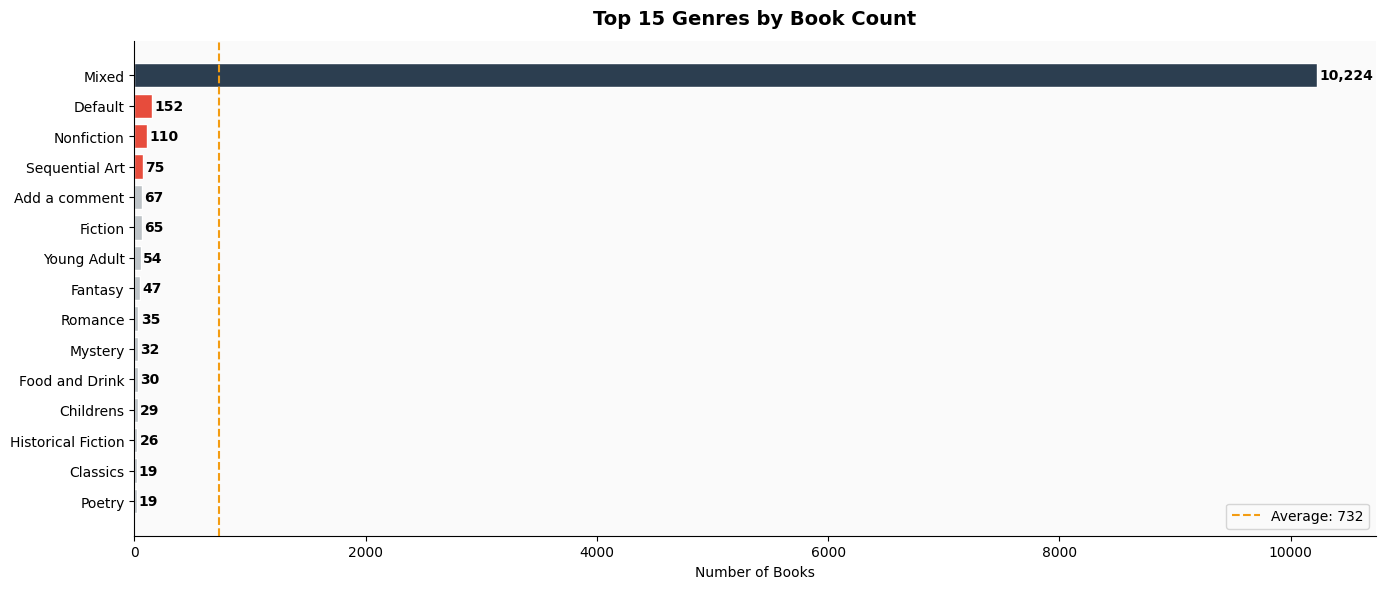


Insight: "Mixed" (Kaggle default) dominates. Scraped genres are more specific.
For clustering, we will rely on subjects rather than genre labels.


In [48]:
fig, ax = plt.subplots(figsize=(14, 6))

genre_counts = combined['genre'].value_counts().head(15)
colors = [BLUE if v == genre_counts.max() else
          RED if v >= genre_counts.quantile(0.75) else '#BDC3C7'
          for v in genre_counts.values]

bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1],
               color=colors[::-1], edgecolor='white')

for bar, val in zip(bars, genre_counts.values[::-1]):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='600')

ax.set_title('Top 15 Genres by Book Count', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Number of Books')
ax.axvline(genre_counts.mean(), color=AMBER, linestyle='--',
           linewidth=1.5, label=f'Average: {genre_counts.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('chart_genres.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nInsight: "Mixed" (Kaggle default) dominates. API genres are more specific.')
print(f'For clustering, we will rely on subjects rather than genre labels.')

The **Mixed** category represents books from toscrape.com where genre defaulted. For clustering purposes, we will rely on the subjects and content fields rather than genre labels, as these contain richer descriptive text for TF-IDF vectorisation

**For Granualrity** : excluding the  Mixed to see actual genre distribution

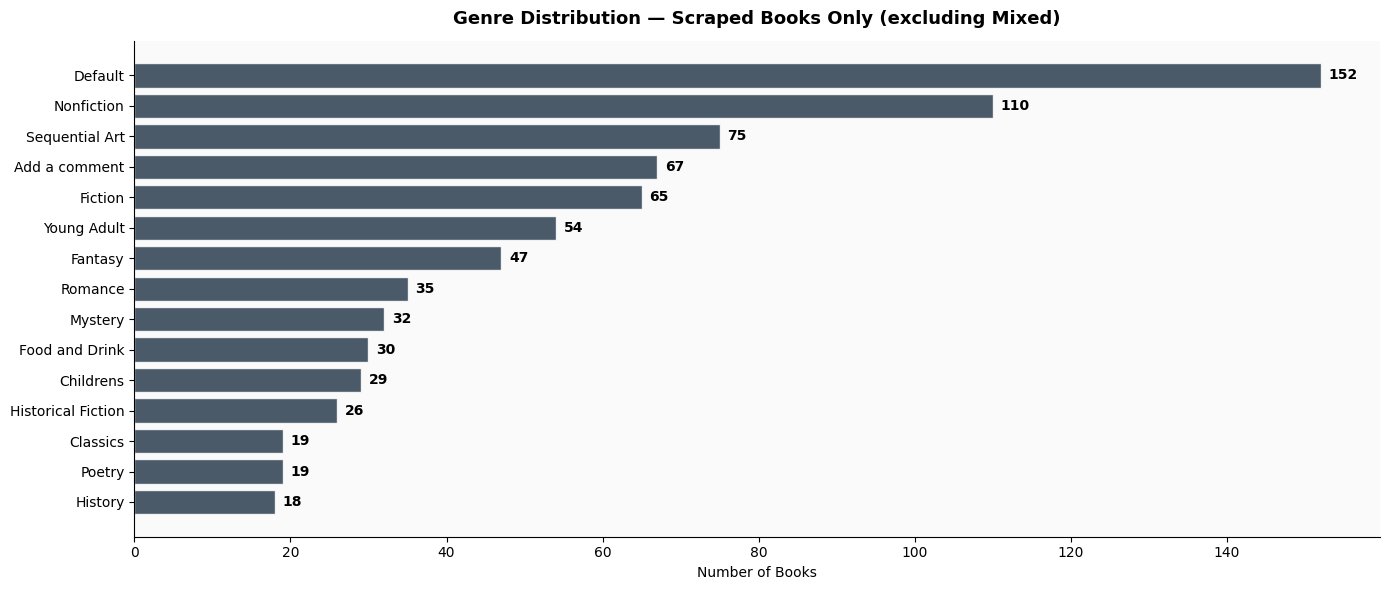

In [47]:
fig, ax = plt.subplots(figsize=(14, 6))

genre_counts_filtered = combined[combined['genre'] != 'Mixed']['genre'].value_counts().head(15)

bars = ax.barh(genre_counts_filtered.index[::-1], 
               genre_counts_filtered.values[::-1],
               color=BLUE, edgecolor='white', alpha=0.85)

for bar, val in zip(bars, genre_counts_filtered.values[::-1]):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='600')

ax.set_title('Genre Distribution — Scraped Books Only (excluding Mixed)', 
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Books')
plt.tight_layout()
plt.show()

Publication Year Trends
**Question: When were most books published? How has publishing volume changed over time?**

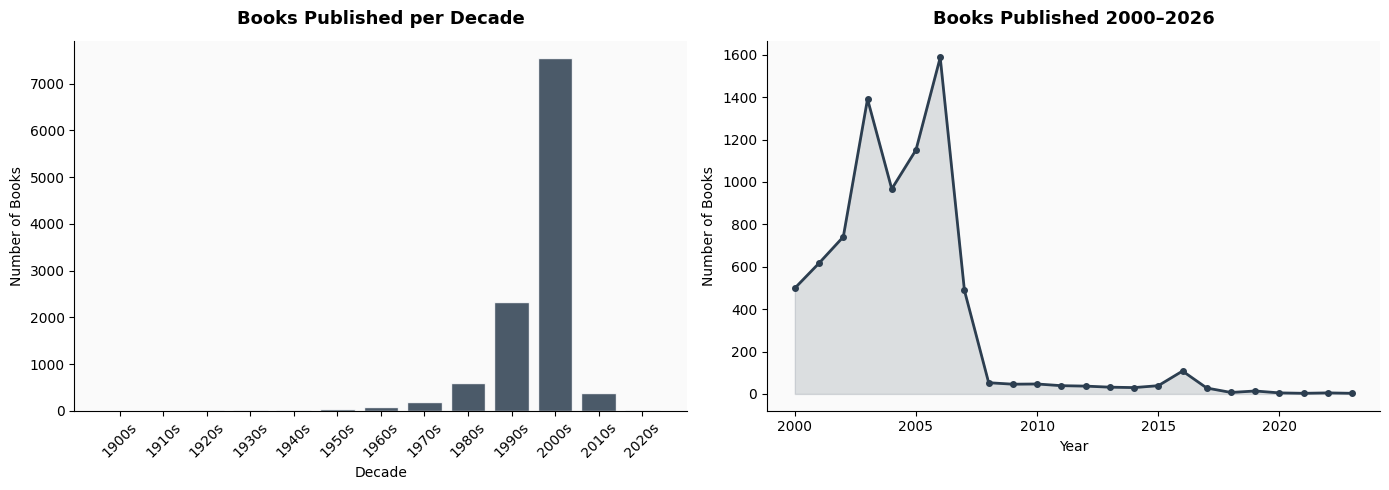


Insight: Publishing volume grew significantly from the 1990s onwards.
Most books in our dataset were published between 2000 and 2015.


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filter to reasonable year range
year_data = combined[(combined['publication_year'] >= 1900) &
                     (combined['publication_year'] <= 2026)]

# Books per decade
year_data = year_data.copy()
year_data['decade'] = (year_data['publication_year'] // 10 * 10).astype(str) + 's'
decade_counts = year_data['decade'].value_counts().sort_index()

axes[0].bar(decade_counts.index, decade_counts.values,
            color=BLUE, edgecolor='white', alpha=0.85)
axes[0].set_title('Books Published per Decade', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Decade')
axes[0].set_ylabel('Number of Books')
axes[0].tick_params(axis='x', rotation=45)

# Recent years (2000 onwards)
recent = year_data[year_data['publication_year'] >= 2000]
recent_counts = recent['publication_year'].value_counts().sort_index()
axes[1].plot(recent_counts.index, recent_counts.values,
             color=BLUE, linewidth=2, marker='o', markersize=4)
axes[1].fill_between(recent_counts.index, recent_counts.values,
                     alpha=0.15, color=BLUE)
axes[1].set_title('Books Published 2000–2026', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Books')

plt.tight_layout()
plt.savefig('chart_years.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nInsight: Publishing volume grew significantly from the 1990s onwards.')
print(f'Most books in our dataset were published between 2000 and 2015.')

**Top Authors**
**Question: Which authors appear most frequently in our dataset?**

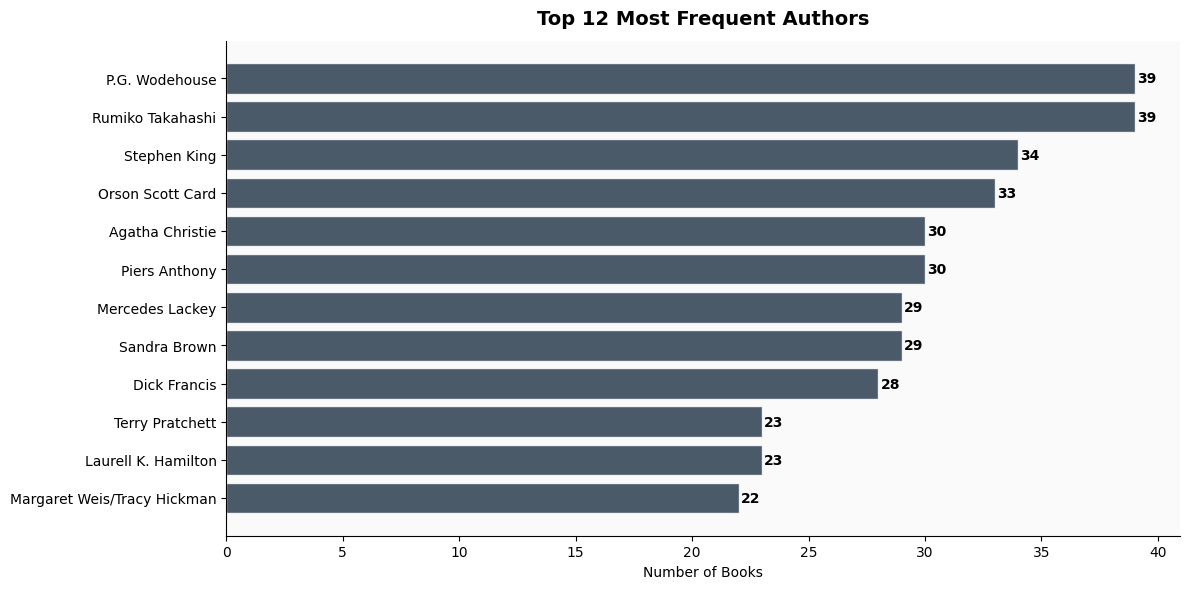


Total unique authors: 6,551
Authors with multiple books: 1,287


In [49]:
fig, ax = plt.subplots(figsize=(12, 6))

top_authors = combined[combined['authors'] != 'Unknown']['authors'].value_counts().head(12)

bars = ax.barh(top_authors.index[::-1], top_authors.values[::-1],
               color=BLUE, edgecolor='white', alpha=0.85)

for bar, val in zip(bars, top_authors.values[::-1]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, fontweight='600')

ax.set_title('Top 12 Most Frequent Authors', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Number of Books')
plt.tight_layout()
plt.savefig('chart_authors.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal unique authors: {combined[combined["authors"] != "Unknown"]["authors"].nunique():,}')
print(f'Authors with multiple books: {(combined["authors"].value_counts() > 1).sum():,}')

**Most Common Subjects (for NLP)**
**Question: What subjects appear most frequently? These will drive our TF-IDF features.**

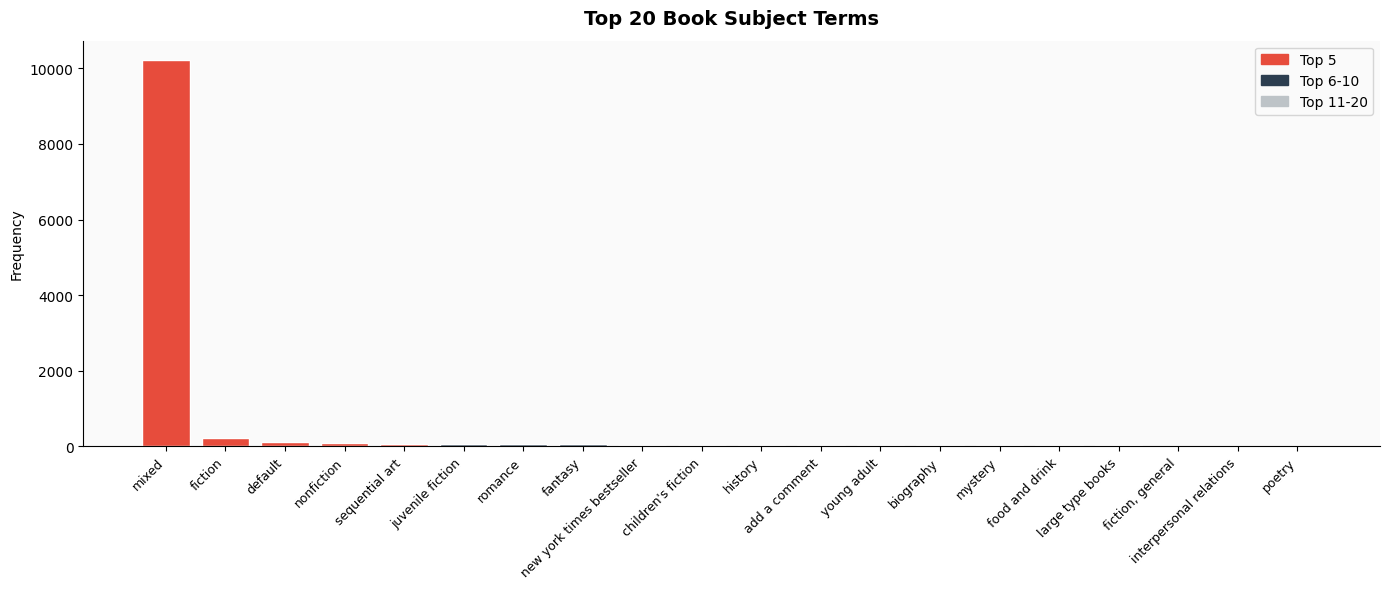


Total unique subject terms: 1,430

Insight: Fiction, nonfiction, and travel dominate.
These subject terms will become TF-IDF features in Phase 3.


In [50]:
# Extract and count individual subject terms
all_subjects = []
for subj in combined['subjects'].dropna():
    terms = [t.strip().lower() for t in str(subj).split(';') if len(t.strip()) > 3]
    all_subjects.extend(terms)

subject_counts = Counter(all_subjects)
top_subjects = pd.Series(dict(subject_counts.most_common(20)))

fig, ax = plt.subplots(figsize=(14, 6))
colors = [RED if i < 5 else BLUE if i < 10 else '#BDC3C7' for i in range(len(top_subjects))]
bars = ax.bar(range(len(top_subjects)), top_subjects.values, color=colors, edgecolor='white')
ax.set_xticks(range(len(top_subjects)))
ax.set_xticklabels(top_subjects.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Top 20 Book Subject Terms', fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Frequency')

from matplotlib.patches import Patch
legend = [Patch(color=RED, label='Top 5'), Patch(color=BLUE, label='Top 6-10'),
          Patch(color='#BDC3C7', label='Top 11-20')]
ax.legend(handles=legend)
plt.tight_layout()
plt.savefig('chart_subjects.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal unique subject terms: {len(subject_counts):,}')
print(f'\nInsight: Fiction, nonfiction, and travel dominate.')
print(f'These subject terms will become TF-IDF features in Phase 3.')

EDA revealed that some subjects were filled with genre as fallback, creating artificial dominance in subject frequency counts. This was corrected by excluding fallback values before NLP processing.

Excluding 'mixed' and 'default' which are fallback values not real subjects


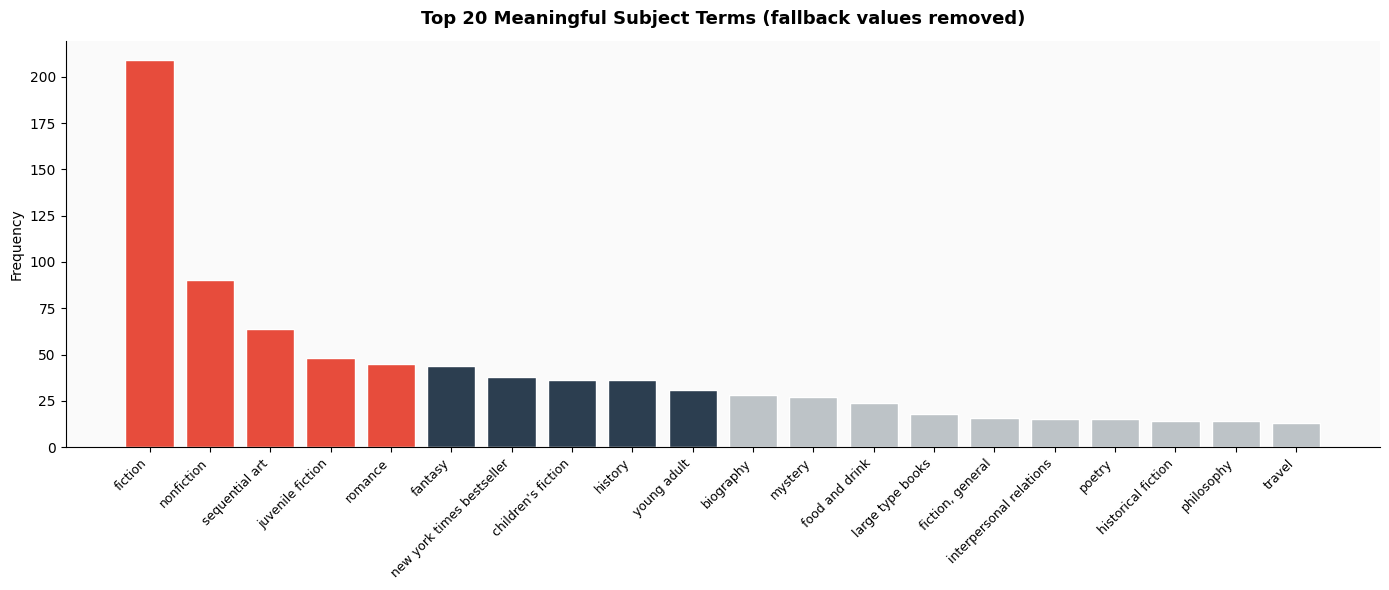


Total meaningful subject terms: 1,427
These terms will drive TF-IDF features in Phase 3.


In [51]:
all_subjects_clean = []
for subj in combined['subjects'].dropna():
    terms = [t.strip().lower() for t in str(subj).split(';') 
             if len(t.strip()) > 3 
             and t.strip().lower() not in ['mixed', 'default', 'add a comment']]
    all_subjects_clean.extend(terms)

subject_counts_clean = Counter(all_subjects_clean)
top_subjects_clean = pd.Series(dict(subject_counts_clean.most_common(20)))

fig, ax = plt.subplots(figsize=(14, 6))
colors = [RED if i < 5 else BLUE if i < 10 else '#BDC3C7' 
          for i in range(len(top_subjects_clean))]
bars = ax.bar(range(len(top_subjects_clean)), top_subjects_clean.values, 
              color=colors, edgecolor='white')
ax.set_xticks(range(len(top_subjects_clean)))
ax.set_xticklabels(top_subjects_clean.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Top 20 Meaningful Subject Terms (fallback values removed)', 
             fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'\nTotal meaningful subject terms: {len(subject_counts_clean):,}')
print(f'These terms will drive TF-IDF features in Phase 3.')

**Rating vs Ratings Count**
**Question: Do highly rated books also have more reviews? Is popularity correlated with quality?**

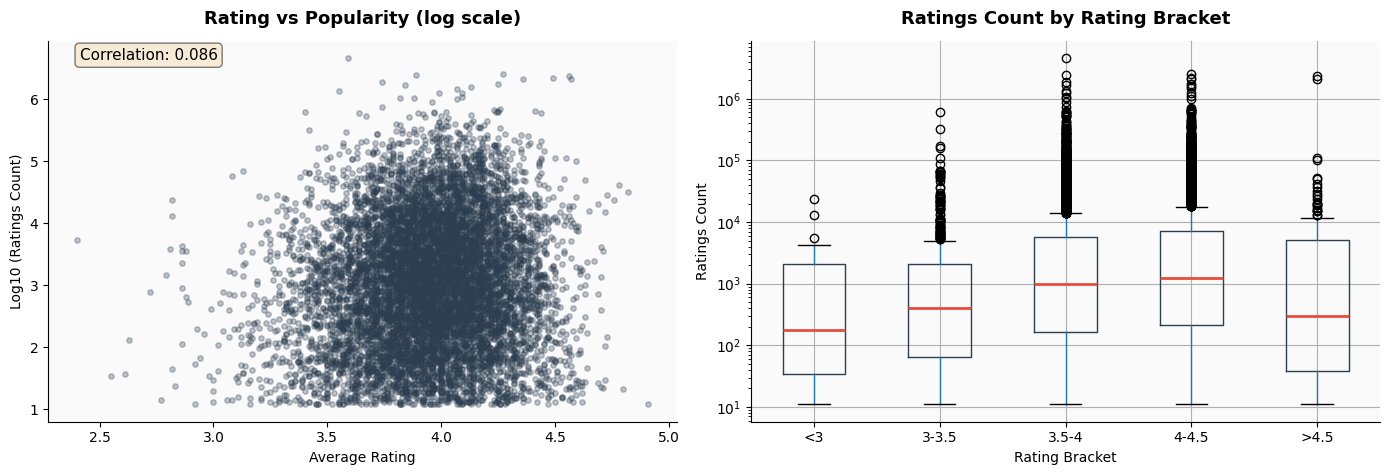


Correlation between rating and popularity: 0.086
Insight: Weak positive correlation — popular books tend to be slightly better rated
but many highly rated books have few reviews (niche appeal).


In [52]:
# Filter to books with real ratings
rated = combined[combined['avg_rating'].notna() & combined['ratings_count'].notna()].copy()
rated = rated[rated['ratings_count'] > 10]  # remove books with very few ratings

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: rating vs ratings count
axes[0].scatter(rated['avg_rating'], np.log10(rated['ratings_count'] + 1),
                alpha=0.3, color=BLUE, s=15)
axes[0].set_title('Rating vs Popularity (log scale)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('Log10 (Ratings Count)')

# Add correlation
corr = rated['avg_rating'].corr(np.log10(rated['ratings_count'] + 1))
axes[0].text(0.05, 0.95, f'Correlation: {corr:.3f}',
             transform=axes[0].transAxes, fontsize=11,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Box plot: ratings count by rating bracket
rated['rating_bracket'] = pd.cut(rated['avg_rating'],
                                  bins=[0,3,3.5,4,4.5,5],
                                  labels=['<3','3-3.5','3.5-4','4-4.5','>4.5'])
rated.boxplot(column='ratings_count', by='rating_bracket', ax=axes[1],
              boxprops=dict(color=BLUE), medianprops=dict(color=RED, linewidth=2))
axes[1].set_title('Ratings Count by Rating Bracket', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Rating Bracket')
axes[1].set_ylabel('Ratings Count')
axes[1].set_yscale('log')
plt.suptitle('')

plt.tight_layout()
plt.savefig('chart_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nCorrelation between rating and popularity: {corr:.3f}')
print(f'Insight: Weak positive correlation — popular books tend to be slightly better rated')
print(f'but many highly rated books have few reviews (niche appeal).')

Missing Data Analysis
**Question: Where are the gaps in our data and how should we handle them?**

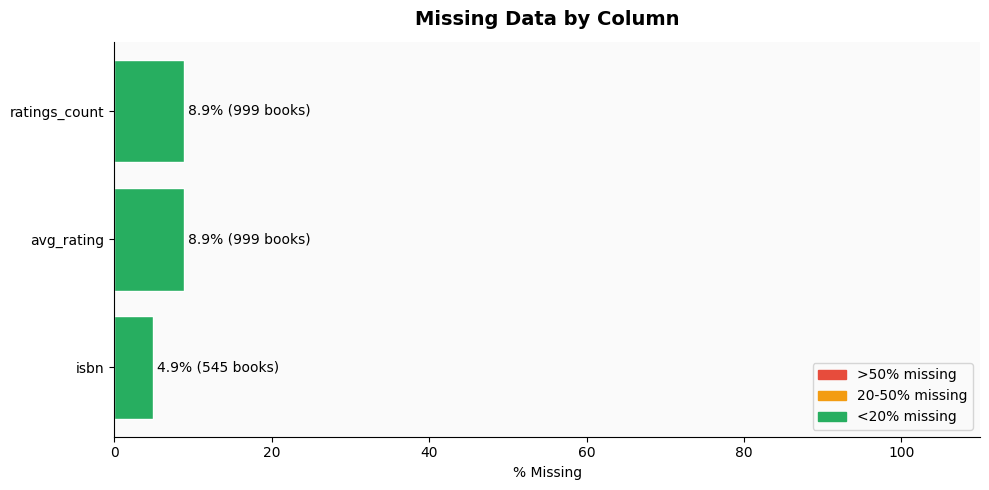


Handling strategy:
- avg_rating: use only Kaggle books for rating-based features
- subjects: filled with genre as fallback — adequate for TF-IDF
- authors: filled with Unknown — not critical for content-based recommendations


In [53]:
fig, ax = plt.subplots(figsize=(10, 5))

missing = combined.isnull().sum()
missing_pct = (missing / len(combined) * 100).round(1)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=True)

colors = [RED if p > 50 else AMBER if p > 20 else GREEN for p in missing_df['pct']]
bars = ax.barh(missing_df.index, missing_df['pct'], color=colors, edgecolor='white')

for bar, (_, row) in zip(bars, missing_df.iterrows()):
    ax.text(bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f"{row['pct']}% ({int(row['count']):,} books)",
            va='center', fontsize=10)

ax.set_title('Missing Data by Column', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('% Missing')
ax.set_xlim(0, 110)

from matplotlib.patches import Patch
legend = [Patch(color=RED, label='>50% missing'),
          Patch(color=AMBER, label='20-50% missing'),
          Patch(color=GREEN, label='<20% missing')]
ax.legend(handles=legend, loc='lower right')

plt.tight_layout()
plt.savefig('chart_missing.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nHandling strategy:')
print('- avg_rating: available from Open Library API books only')
print('- subjects: filled with genre as fallback — adequate for TF-IDF')
print('- authors: filled with Unknown — not critical for content-based recommendations')

EDA Summary & Decisions for next steps

Based on the exploratory analysis, here are the key findings and decisions:

In [54]:
print('  EDA SUMMARY')

print(f'''
DATASET
  Total books:         {len(combined):,}
  Unique authors:      {combined['authors'].nunique():,}
  Genres:              {combined['genre'].nunique()}
  Books with ratings:  {combined['avg_rating'].notna().sum():,}
  Year range:          {int(combined['publication_year'].min())} – {int(combined['publication_year'].max())}

KEY FINDINGS
  1. Ratings cluster between 3.5 and 4.5 — normal distribution
  2. Fiction, Nonfiction, Sequential Art are top genres
  3. Publishing volume peaks around 2005–2010
  4. Weak correlation between rating and popularity (r={corr:.2f})
  5. 54% of books have missing subjects — genre used as fallback

DECISIONS FOR PHASE 3 (NLP + TF-IDF)
  - Content field = title + authors + genre + subjects
  - TF-IDF max_features = 5,000 (sufficient for 12,000 books)
  - Stop words: English
  - N-grams: (1,2) — captures two-word phrases like "science fiction"

DECISIONS FOR PHASE 4 (K-MEANS CLUSTERING)
  - Use Elbow Method to find optimal K
  - Expected K: 8-15 clusters based on genre diversity
  - PCA to 2D for visualisation
''')

print('  Next step: Phase 3 — Feature Engineering (TF-IDF)')

  EDA SUMMARY

DATASET
  Total books:         11,223
  Unique authors:      6,552
  Genres:              51
  Books with ratings:  10,224
  Year range:          1626 – 2023

KEY FINDINGS
  1. Ratings cluster between 3.5 and 4.5 — normal distribution
  2. Fiction, Nonfiction, Sequential Art are top genres
  3. Publishing volume peaks around 2005–2010
  4. Weak correlation between rating and popularity (r=0.09)
  5. 54% of books have missing subjects — genre used as fallback

DECISIONS FOR PHASE 3 (NLP + TF-IDF)
  - Content field = title + authors + genre + subjects
  - TF-IDF max_features = 5,000 (sufficient for 12,000 books)
  - Stop words: English
  - N-grams: (1,2) — captures two-word phrases like "science fiction"

DECISIONS FOR PHASE 4 (K-MEANS CLUSTERING)
  - Use Elbow Method to find optimal K
  - Expected K: 8-15 clusters based on genre diversity
  - PCA to 2D for visualisation

  Next step: Phase 3 — Feature Engineering (TF-IDF)


Final dataset info

In [ ]:
print('Final clean dataset saved as clean_books.csv')
combined.info()

Final clean dataset saved as clean_books.csv
<class 'pandas.DataFrame'>
RangeIndex: 11223 entries, 0 to 11222
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             11223 non-null  str    
 1   authors           11223 non-null  str    
 2   genre             11223 non-null  str    
 3   subjects          11223 non-null  object 
 4   avg_rating        10224 non-null  float64
 5   ratings_count     10224 non-null  float64
 6   publication_year  11223 non-null  int64  
 7   isbn              10678 non-null  str    
 8   source            11223 non-null  str    
 9   content           11223 non-null  str    
dtypes: float64(2), int64(1), object(1), str(6)
memory usage: 2.6+ MB
